In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk
import templateflow.api as tflow

In [2]:
pd.options.display.max_colwidth = 100

## Load results

In [79]:
OUTPUT_DIR = Path("output")

records = []
for jsonl in OUTPUT_DIR.glob("*/results.jsonl"):
    records.extend(pd.read_json(jsonl, lines=True).to_dict("records"))

df = pd.DataFrame(records)


# Parse stop condition into convergence type and iteration count
def parse_stop_cond(s):
    m = re.search(r"Convergence checker passed at iteration (\d+)", s)
    if m:
        return "converged", int(m.group(1))
    m = re.search(r"Maximum number of iterations \((\d+)\)", s)
    if m:
        return "max_iter", int(m.group(1))
    return "unknown", None


df[["stop_type", "n_iter"]] = df["stop_cond"].apply(parse_stop_cond).apply(pd.Series)
df["input"] = df["input"].apply(lambda p: Path(p).name)
df["final_metric"] = -df["final_metric"]

df = df.drop_duplicates(["version", "input"], keep="last")

print("\nFinal metric:")
print(df.groupby("version")["final_metric"].describe().round(3))
print("\nRun time:")
print(df.groupby("version")["run_time"].describe().round(3))
print("\nStop type counts:")
print(df.groupby(["version", "stop_type"]).size())


Final metric:
         count   mean    std    min    25%    50%    75%    max
version                                                        
v1        64.0  0.364  0.084  0.100  0.327  0.382  0.411  0.522
v10       54.0  0.529  0.081  0.313  0.498  0.534  0.572  0.698
v11       16.0  0.541  0.068  0.401  0.505  0.540  0.586  0.654
v2        31.0  0.406  0.048  0.304  0.380  0.400  0.433  0.507
v3        64.0  0.343  0.103  0.091  0.307  0.368  0.413  0.507
v4        27.0  0.069  0.025  0.036  0.045  0.072  0.082  0.127
v5        64.0  0.363  0.083  0.131  0.330  0.379  0.410  0.484
v6        14.0  0.265  0.115  0.017  0.187  0.267  0.361  0.415
v7        64.0  0.370  0.084  0.129  0.350  0.388  0.413  0.500
v8        64.0  0.530  0.082  0.315  0.491  0.534  0.577  0.699
v9        38.0  0.264  0.057  0.135  0.228  0.270  0.296  0.381

Run time:
         count    mean    std    min     25%     50%     75%     max
version                                                             
v1  

In [80]:
bad_images = df.loc[df["version"] == "v1"].sort_values("final_metric")["input"].values[:5].tolist()
# print(df.set_index(["input", "version"]).sort_index().loc[bad_images, ["final_metric", "run_time"]].head(20))

## Histograms

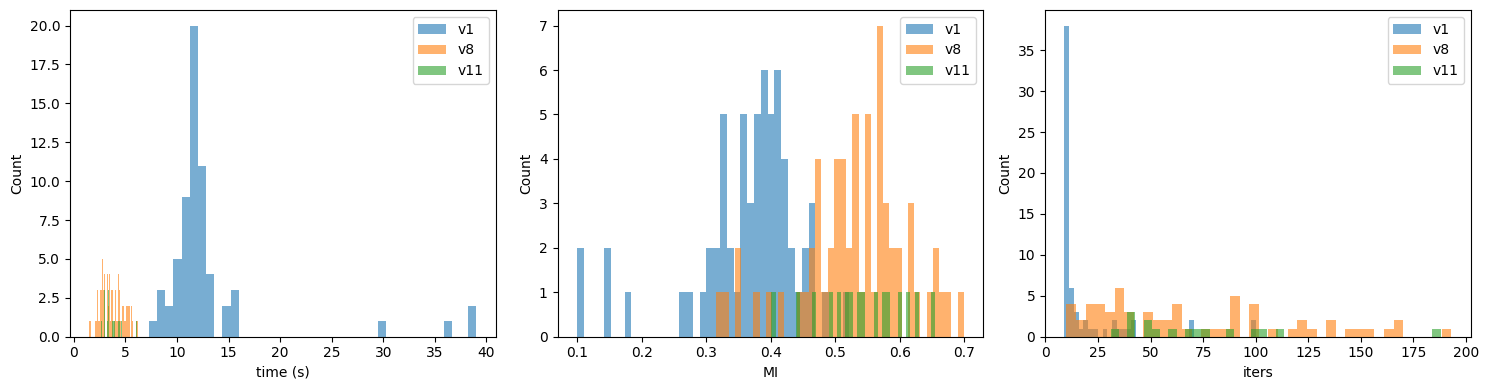

In [81]:
# versions = sorted(df["version"].unique())
versions = ["v1", "v8", "v11"]

metrics = [
    ("run_time", "time (s)"),
    ("final_metric", "MI"),
    ("n_iter", "iters"),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))

for ax, (col, label) in zip(axes, metrics):
    for version in versions:
        vals = df.loc[df["version"] == version, col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, label=version)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()

fig.tight_layout()

## Image grid — axial middle slice with template outline

In [67]:
template_mask_path = tflow.get(
    "MNI152NLin6Asym", desc="brain", resolution=1, suffix="mask", extension="nii.gz"
)
template_mask = sitk.GetArrayFromImage(sitk.ReadImage(str(template_mask_path)))  # (Z, Y, X)
# template_mask_path = tflow.get(
#     "MNI152NLin6Asym", desc=None, resolution=1, suffix="T1w", extension="nii.gz"
# )
# template_mask = sitk.GetArrayFromImage(sitk.ReadImage(str(template_mask_path)))  # (Z, Y, X)
# template_mask = template_mask > 500
mid_z = template_mask.shape[0] // 2
template_mask_slice = template_mask[mid_z]

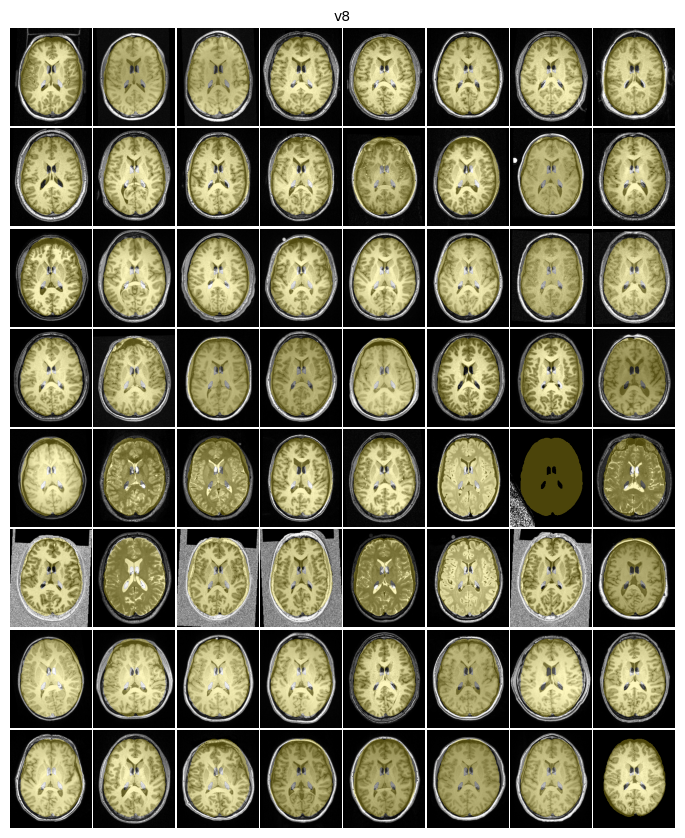

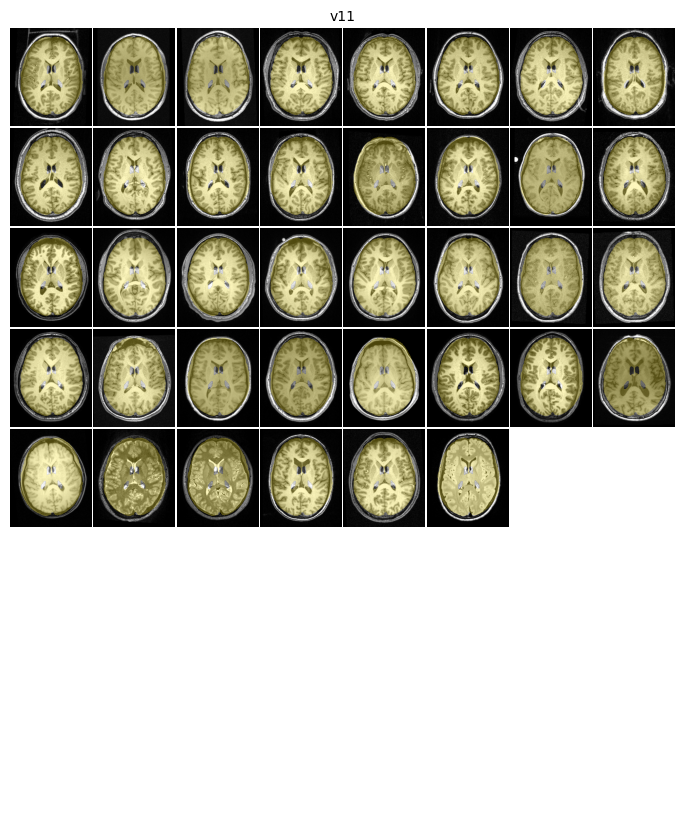

In [84]:
def image_grid(version, nrow: int = 8, ncol: int = 8):
    img_paths = sorted((OUTPUT_DIR / version).glob("*.nii*"))
    img_paths = img_paths[: nrow * ncol]
    H, W = template_mask_slice.shape
    ploth = 1.0
    plotw = (W / H) * ploth
    padh = 0.2

    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * plotw, nrow * ploth + padh))
    axes = axes.ravel()

    for ii, ax in enumerate(axes):
        if ii >= len(img_paths):
            ax.axis("off")
            continue
        path = img_paths[ii]
        arr = sitk.GetArrayFromImage(sitk.ReadImage(str(path)))
        sl = arr[mid_z]
        vmax = np.percentile(sl, 99)
        ax.imshow(sl, cmap="gray", vmin=0, vmax=vmax, origin="lower")
        ax.imshow(
            np.where(template_mask_slice > 0, 1.0, np.nan), vmin=0.0, alpha=0.3, origin="lower"
        )
        ax.axis("off")

    fig.suptitle(version, y=1.001, fontsize=10)
    fig.tight_layout(pad=0.1)


for version in ["v8", "v11"]:
    image_grid(version)

In [85]:
img_paths = sorted((OUTPUT_DIR / "v8").glob("*.nii*"))
img_paths[37:40]

[PosixPath('output/v8/ds000221__sub-010036_ses-01_acq-highres_FLAIR.nii.gz'),
 PosixPath('output/v8/ds000221__sub-010041_ses-01_T2w.nii.gz'),
 PosixPath('output/v8/ds000221__sub-010092_ses-01_T2w.nii.gz')]